In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Generate data

In [79]:
x = np.arange(0,4*np.pi,0.1) #start,stop,step
y = 2*np.sin(x) + np.random.normal(0,1,size=len(x))

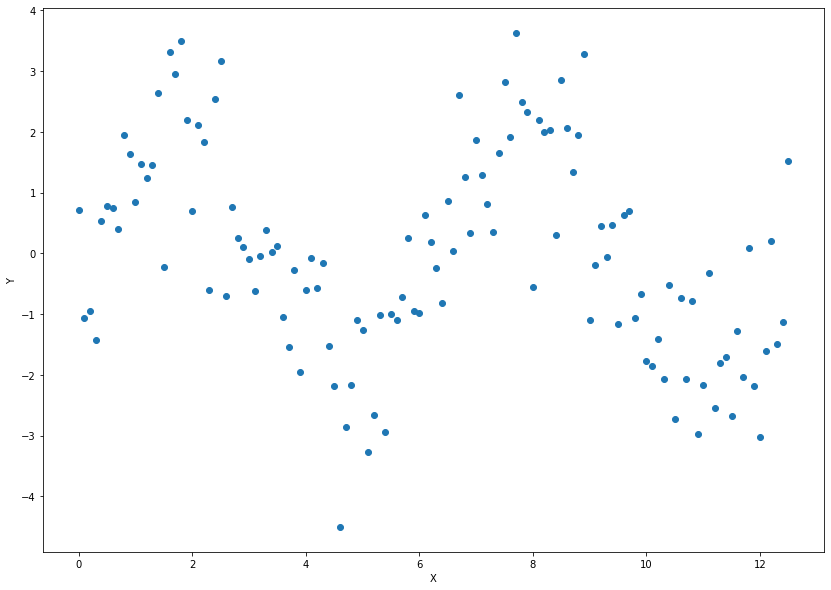

In [80]:
plt.figure(figsize=(14,10))
plt.scatter(x,y)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


## Fit LWR model (Ineffiecient implementation)

Objective for LWR is:

$$
J(\theta) = \sum\limits_{i=1}^{m}\omega_i\left(\theta^{T}x^i-y^i\right)^2
$$

Corresponding **maximum likelihood estimate** is:-

$$
\hat{\theta} = \frac{\sum\limits_{i=1}^{m}\omega_i x_i y_i}{\sum\limits_{i=1}^{m}\omega_i x_i^2}
$$

To think about:
- What change was introduced to an LWR model to turn it into a non-parametric model from a parametric one?

In [335]:
# define weight function
def w(test_x,x,k=0.5): 
    # k - is the bandwidth parameter, and controls how quickly 
    #     the w falls with distance from test_x 
    return np.exp(-(test_x-x)**2 / (2*k**2))

In [336]:
# we will test the model at the same locations as the trained model
query_points = x
#query_points = np.linspace(0,14,len(x))
y_pred = np.zeros_like(query_points)

In [337]:
# looping over each point we want to test
for i in range(len(query_points)):
    
    theta1 = 0
    for j in range(len(x)): # m = len(x)
        w_j = w(query_points[i],x[j])
        theta1 +=w_j*x[j]*y[j]
        
    theta2 = 0
    for j in range(len(x)): # m = len(x)
        w_j = w(query_points[i],x[j])
        theta2 +=w_j*x[j]*x[j]
    
    theta = theta1/theta2
    
    y_pred[i] = theta*query_points[i]

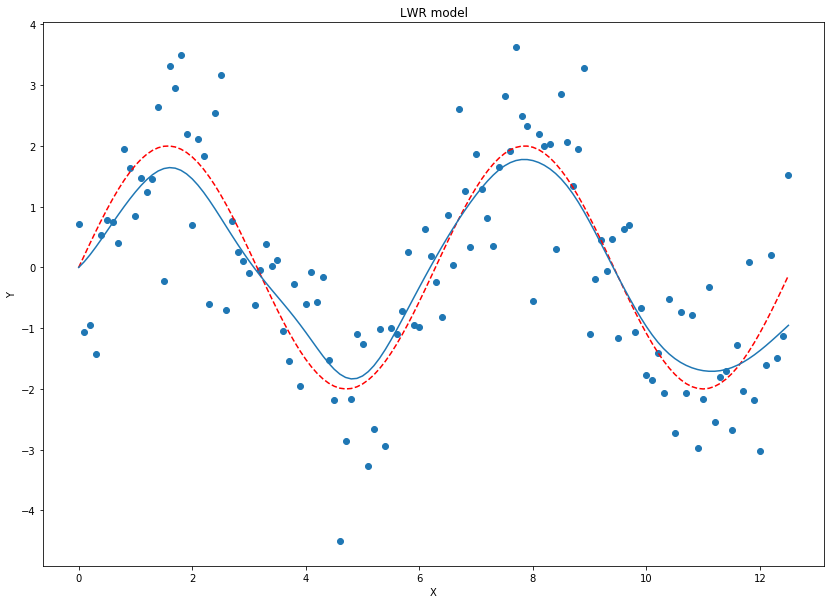

In [338]:
plt.figure(figsize=(14,10))
plt.scatter(x,y)
plt.plot(x,2*np.sin(x),"r--")
plt.plot(query_points,y_pred)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("LWR model")
plt.show()

model seems to treat other data points as outliers

## Fit LWR model (Efficient Implementation)

In [275]:
x = np.arange(0,4*np.pi,0.1) #start,stop,step
query_points = x

In [331]:
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel
# define weight function (one that outputs a diagonal matrix)
def W(query_point,x,k=0.5): 
    # k - is the bandwidth parameter, and controls how quickly 
    #     the w falls with distance from test_x 
    M = x.shape[0]
    W = np.mat(np.eye(M)) 
    # calculating weights for query points 
    for i in range(M): 
        denominator = (-2 * k * k) 
        W[i, i] = np.exp(np.dot((x[i]-query_point), (x[i]-query_point).T)/denominator) 
    return W 

In [332]:
theta = np.zeros_like(query_points)
for i in range(len(query_points)):

    w = W(query_points[i],x)
    
    # inv = np.linalg.inv(A)
    # result = inv*d
    
    # np.linalg.solve(A,d)
    theta[i] = np.linalg.solve(x.T @ w @ x,x.T @ w @ y)
    

In [333]:
y_pred = theta*query_points

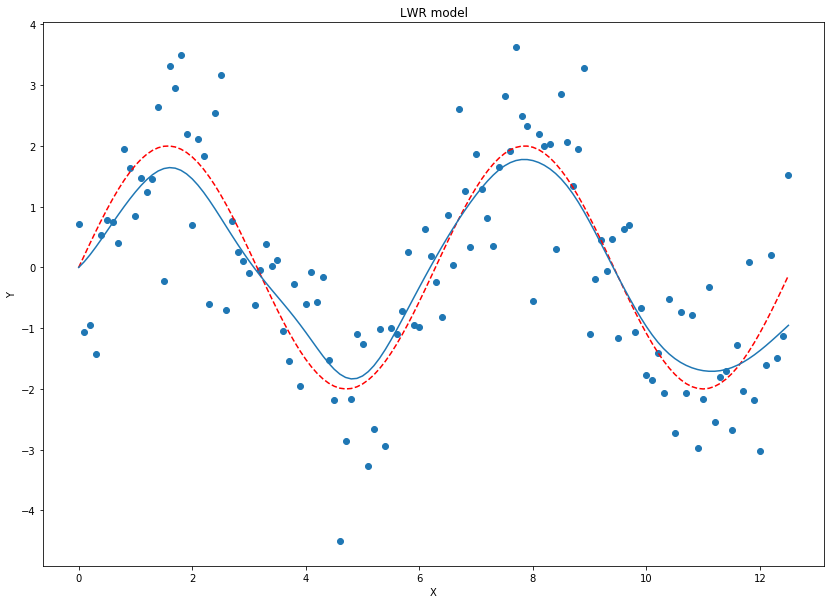

In [334]:
plt.figure(figsize=(14,10))
plt.scatter(x,y)
plt.plot(x,2*np.sin(x),"r--")
plt.plot(query_points,y_pred)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("LWR model")
plt.show()